Epoch 0, Loss = 53.743767
Epoch 100, Loss = 0.231905
Epoch 200, Loss = 0.077454
Epoch 300, Loss = 0.039823
Epoch 400, Loss = 0.016280
Epoch 500, Loss = 0.010857
Epoch 600, Loss = 0.006039
Epoch 700, Loss = 0.004121
Epoch 800, Loss = 0.004017
Epoch 900, Loss = 0.003502
Epoch 1000, Loss = 0.003674
Epoch 1100, Loss = 0.001176
Epoch 1200, Loss = 0.002063
Epoch 1300, Loss = 0.005184
Epoch 1400, Loss = 0.004970
Epoch 1500, Loss = 0.001076
Epoch 1600, Loss = 0.002781
Epoch 1700, Loss = 0.000693
Epoch 1800, Loss = 0.000627
Epoch 1900, Loss = 0.003021


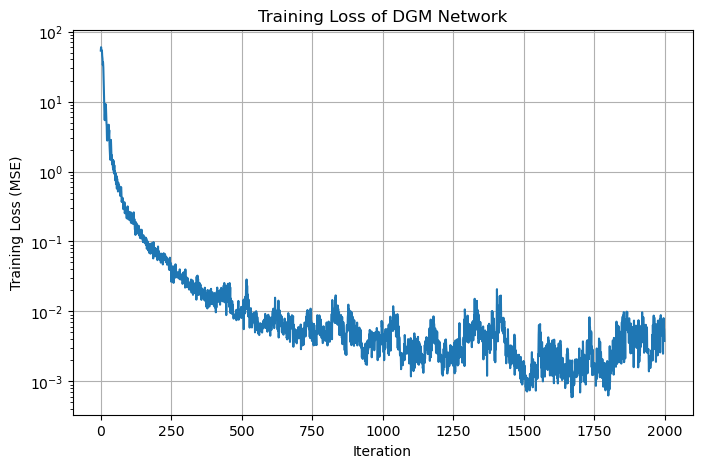

In [ ]:
#Question2.1
import torch

from EX1_1 import LQR

# Step 1: Initialize the LQR model



H = torch.tensor([[0.1, 0.0],
                  [0.0, 0.1]], dtype=torch.float32)

M = torch.eye(2)
C = torch.eye(2)
D = torch.eye(2)
R = torch.eye(2)

sigma = 0.2 * torch.eye(2)
T = 1.0

lqr = LQR(H, M, C, D, R, sigma, T)

# Time grid used to solve the Riccati equation, producing the corresponding matrices S(t_i)
# and scalars g(t_i) for 0 <= i <= 200 and 0 < t_i < T.
time_grid = torch.linspace(0, T, 200)
lqr.solve_riccati(time_grid)




# Step 2:  Generate training data

def generate_training_data(N):
    """
    Generate supervised learning data:
    input: (t, x)
    output: v(t, x)

    N: number of samples
    """

    # Sampling t ~ U[0,1]
    t = torch.rand(N, 1)

    # Sampling x ~ U([-3,3]^2)
    x = -3 + 6 * torch.rand(N, 2)

    x_input = x.unsqueeze(1)#Change (N,2) to（N,1,2）

    # Use Ex1_1 to get value function
    y = lqr.value_function(t.squeeze(), x_input)   # shape (N,1) 

    return t, x, y



from lib.dgm import Net_DGM   

# Network initializatio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim_x = 2          # x is two-dimensional.
hidden_size = 100  # Topic request

model = Net_DGM(dim_x=dim_x, dim_S=hidden_size).to(device)



import torch.nn as nn
import matplotlib.pyplot as plt


# Hyperparameter

N_train = 5000 #Generate 5000 datas


epochs = 2000 # Execute 2000 training cycles
batch_size = 256 # At each update step, 256 samples are randomly drawn from the 5000 data points.
learning_rate = 1e-3 #Learning rate gradient descent step size

# generate data
t_data, x_data, y_data = generate_training_data(N_train)

# Move to device
t_data = t_data.to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)#True value

# optimizer + loss
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Record loss
loss_history = []



# Training loop

for epoch in range(epochs):

    # random batch
    idx = torch.randint(0, N_train, (batch_size,))
    t_batch = t_data[idx]
    x_batch = x_data[idx]
    y_batch = y_data[idx]


    # First, guess an initial set of parameters for the neural network
    # (these are the internal network parameters, not the original HJB parameters).
    # Then use this parameter set to produce a numerical approximation of v.
   
    pred = model(t_batch, x_batch)   # (batch,1)
  
    

   
    loss = loss_fn(pred, y_batch)## y_batch stores the ground-truth values for a randomly sampled batch.
    
    # Backward pass: determine the parameter update direction from the loss.

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    # print
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")



plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss of DGM Network")
plt.yscale("log")   
plt.grid()
plt.show()


Epoch 0, Loss = 2.991812
Epoch 100, Loss = 0.006186
Epoch 200, Loss = 0.000913
Epoch 300, Loss = 0.000588
Epoch 400, Loss = 0.000459
Epoch 500, Loss = 0.000378
Epoch 600, Loss = 0.000309
Epoch 700, Loss = 0.000354
Epoch 800, Loss = 0.000339
Epoch 900, Loss = 0.000281
Epoch 1000, Loss = 0.000274
Epoch 1100, Loss = 0.000255
Epoch 1200, Loss = 0.000241
Epoch 1300, Loss = 0.000196
Epoch 1400, Loss = 0.000213
Epoch 1500, Loss = 0.000224
Epoch 1600, Loss = 0.000242
Epoch 1700, Loss = 0.000187
Epoch 1800, Loss = 0.000161
Epoch 1900, Loss = 0.000168


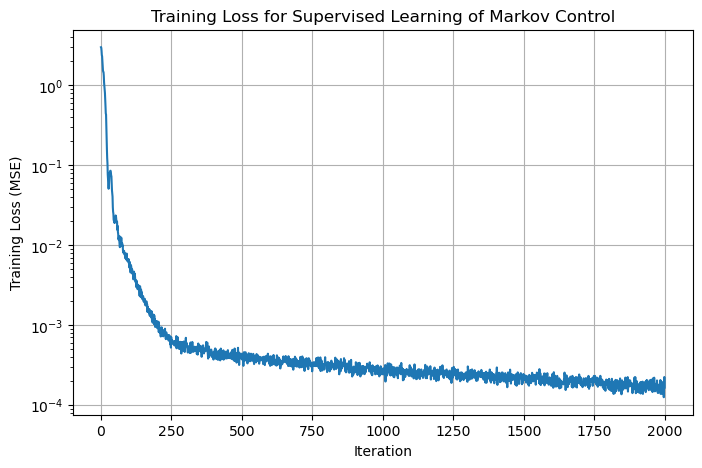

In [ ]:
# Question 2.2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from EX1_1 import LQR
from lib.networks import FFN


def generate_control_training_data(N):
    """
    Generate supervised learning data:
    input: (t, x)
    output: a(t, x)

    N: number of samples
    """

    # Sample t ~ U[0,1]
    t_ctrl = torch.rand(N, 1)

    # Sample x ~ U([-3,3]^2)
    x_ctrl = -3 + 6 * torch.rand(N, 2)

    # Reshape x from (N, 2) to (N, 1, 2)
    x_input_ctrl = x_ctrl.unsqueeze(1)

    # True control labels from Ex1_1, shape (N, 2)
    a_data = lqr.optimal_control(t_ctrl.squeeze(), x_input_ctrl)

    return t_ctrl, x_ctrl, a_data


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FFN: input_dim=3, two hidden layers of size 100, output_dim=2
model_ctrl = FFN(
    sizes=[3, 100, 100, 2],   # 3 -> 100 -> 100 -> 2
    activation=nn.ReLU,       
    output_activation=nn.Identity,
    batch_norm=False
).to(device)


# Hyperparameter

N_train = 5000
epochs = 2000
batch_size = 256
learning_rate = 1e-3

# Generate training data
t_data_ctrl, x_data_ctrl, a_data = generate_control_training_data(N_train)

# Move data to the device
t_data_ctrl = t_data_ctrl.to(device)   # (N,1)
x_data_ctrl = x_data_ctrl.to(device)   # (N,2)
a_data = a_data.to(device)             # (N,2)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(model_ctrl.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

# Record training loss
loss_history = []



# Training loop

for epoch in range(epochs):

    # 从训练集里随机抽一个 mini-batch
    idx = torch.randint(0, N_train, (batch_size,))

    t_batch_ctrl = t_data_ctrl[idx]   # (batch,1)
    x_batch_ctrl = x_data_ctrl[idx]   # (batch,2)
    a_batch = a_data[idx]             # (batch,2)

    # 拼接输入
    input_batch_ctrl = torch.cat([t_batch_ctrl, x_batch_ctrl], dim=1)

    # forward：predict control
    a_pred = model_ctrl(input_batch_ctrl)   # (batch,2)

    # loss：MSE
    loss = loss_fn(a_pred, a_batch)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Record loss
    loss_history.append(loss.item())

    # Print
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")



# 画图

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss for Supervised Learning of Markov Control")
plt.yscale("log")
plt.grid()
plt.show()